In [2]:
import sys
sys.path.insert(0, r"D:\OCRbyGPU\PIL_fix")
import os
import cv2  
import ultralytics
from ultralytics import YOLO
model = YOLO(r'c:\Users\HP\Desktop\ID_OCR\detect_id_card.pt')
import matplotlib.pyplot as plt
import numpy as np

In [3]:
field_model = YOLO(
    r"c:\Users\HP\Desktop\ID_OCR\best.pt"
)

Shape: (580, 916, 3)


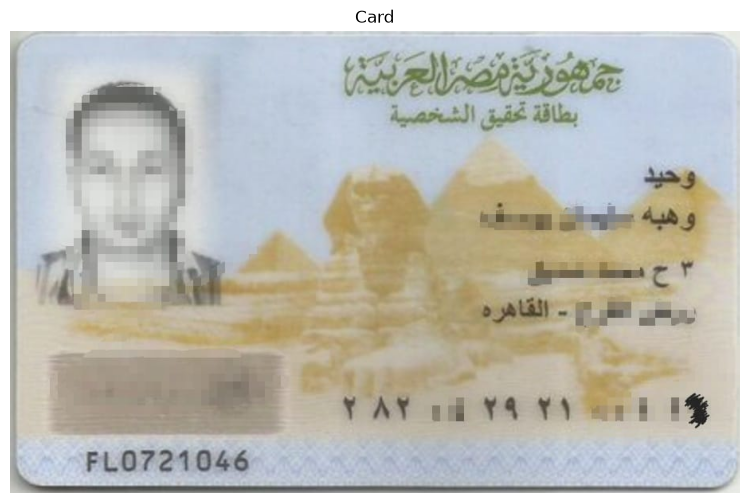

In [4]:
card = cv2.imread(
    "test.jpeg"
)

print("Shape:", card.shape)

plt.figure(figsize=(10, 6))

plt.imshow(
    cv2.cvtColor(
        card,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Card")

plt.axis("off")

plt.show()

In [5]:
results = field_model(
    card,
    imgsz=640,
    
    conf=0.5,

)[0]


0: 416x640 1 Add1, 1 Add2, 1 Face, 1 Name1, 1 Name2, 1 Num1, 1 Num2, 74.9ms
Speed: 2.3ms preprocess, 74.9ms inference, 12.0ms postprocess per image at shape (1, 3, 416, 640)


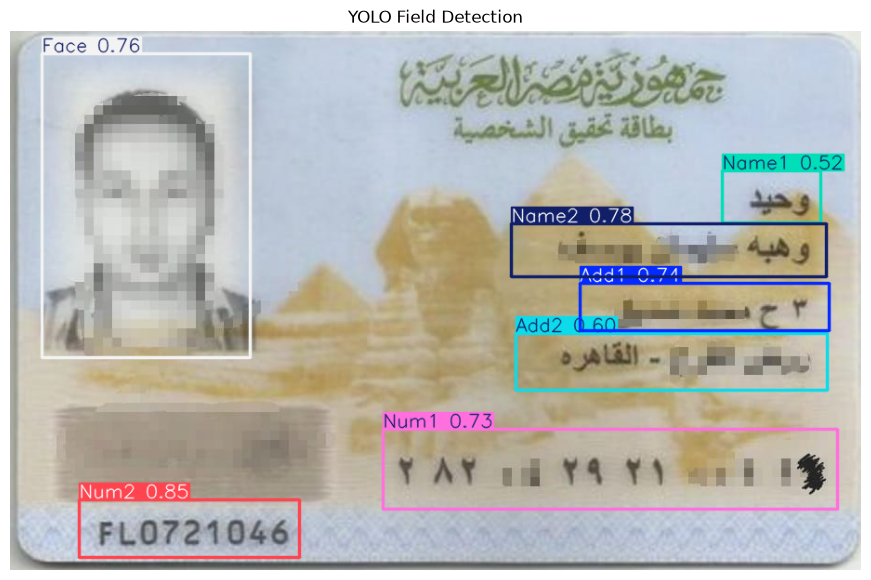

In [6]:
annotated = results.plot()

plt.figure(figsize=(12, 7))

plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("YOLO Field Detection")

plt.axis("off")

plt.show()

In [7]:
boxes = results.boxes.xyxy.cpu().numpy()

print(boxes)
print("Shape:", boxes.shape)
print(50*"-")
classes = results.boxes.cls.cpu().numpy().astype(int)
print(classes)
print(50*"-")
names = results.names
print(names)

[[      74.24      504.32      311.12      566.88]
 [     539.78      207.98      878.62      264.58]
 [      34.01      24.934      258.88      351.51]
 [      613.4      271.21      881.84      322.64]
 [     401.02      428.59      890.99      514.33]
 [     544.29      325.73      879.29      386.62]
 [     766.96      150.44      872.13      206.33]]
Shape: (7, 4)
--------------------------------------------------
[6 4 2 0 5 1 3]
--------------------------------------------------
{0: 'Add1', 1: 'Add2', 2: 'Face', 3: 'Name1', 4: 'Name2', 5: 'Num1', 6: 'Num2'}


In [8]:
for box, cls in zip(boxes, classes):

    box = box.astype(int)

    print("Class ID:", cls)
    print("Class Name:", names[cls])
    print("Box:", box)
    print()

Class ID: 6
Class Name: Num2
Box: [ 74 504 311 566]

Class ID: 4
Class Name: Name2
Box: [539 207 878 264]

Class ID: 2
Class Name: Face
Box: [ 34  24 258 351]

Class ID: 0
Class Name: Add1
Box: [613 271 881 322]

Class ID: 5
Class Name: Num1
Box: [401 428 890 514]

Class ID: 1
Class Name: Add2
Box: [544 325 879 386]

Class ID: 3
Class Name: Name1
Box: [766 150 872 206]



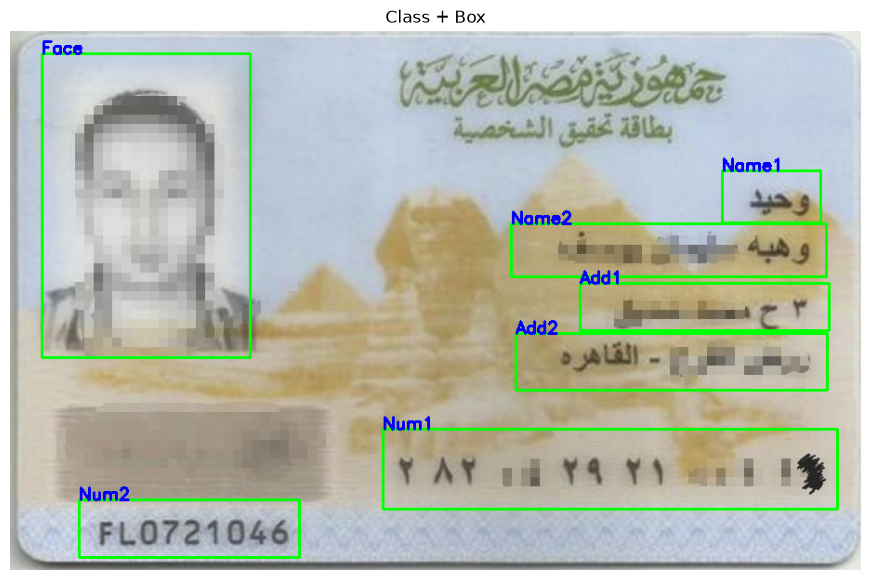

In [9]:
image = card.copy()

for box, cls in zip(boxes, classes):
    x1, y1, x2, y2 = box.astype(int)
    label = names[cls]
    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )
    cv2.putText(
        image,
        label,
        (x1, y1 ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )
plt.figure(figsize=(12, 7))
plt.imshow(
    cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Class + Box")
plt.axis("off")
plt.show()

In [10]:
name_box = None
number_box = None

for box, cls in zip(boxes, classes):

    label = names[cls]

    if label == "Name2":
        name_box = box.astype(int)

    elif label == "Num1":
        number_box = box.astype(int)

print("Name2 Box:", name_box)
print("Num1 Box:", number_box)

Name2 Box: [539 207 878 264]
Num1 Box: [401 428 890 514]


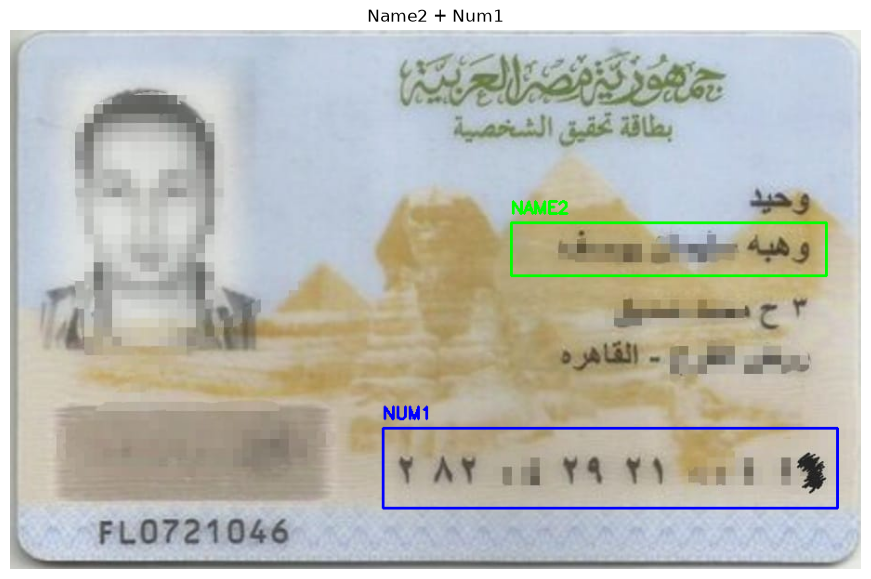

In [11]:
selected = card.copy()

x1, y1, x2, y2 = name_box

cv2.rectangle(
    selected,
    (x1, y1),
    (x2, y2),
    (0, 255, 0),
    2
)

cv2.putText(
    selected,
    "NAME2",
    (x1, y1 - 10),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.6,
    (0, 255, 0),
    2
)

x1, y1, x2, y2 = number_box

cv2.rectangle(
    selected,
    (x1, y1),
    (x2, y2),
    (255, 0, 0),
    2
)

cv2.putText(
    selected,
    "NUM1",
    (x1, y1 - 10),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.6,
    (255, 0, 0),
    2
)

plt.figure(figsize=(12, 7))

plt.imshow(
    cv2.cvtColor(
        selected,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Name2 + Num1")

plt.axis("off")

plt.show()

In [12]:
name_x1, name_y1, name_x2, name_y2 = name_box

print("Name2:")
print("x1 =", name_x1)
print("y1 =", name_y1)
print("x2 =", name_x2)
print("y2 =", name_y2)

num_x1, num_y1, num_x2, num_y2 = number_box

print("Num1:")
print("x1 =", num_x1)
print("y1 =", num_y1)
print("x2 =", num_x2)
print("y2 =", num_y2)

distance = num_y1 - name_y2

print(
    "Vertical Distance:",
    distance,
    "pixels"
)

Name2:
x1 = 539
y1 = 207
x2 = 878
y2 = 264
Num1:
x1 = 401
y1 = 428
x2 = 890
y2 = 514
Vertical Distance: 164 pixels


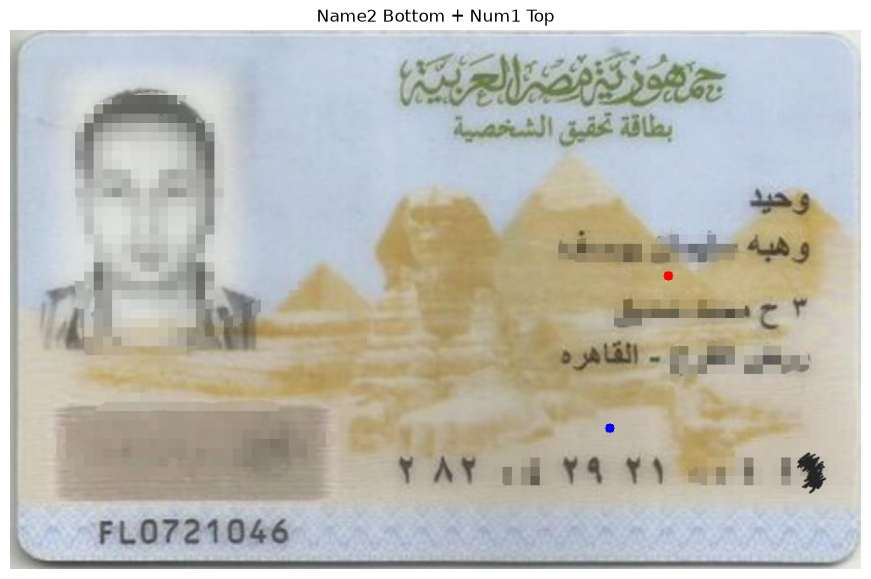

In [13]:
distance_image = card.copy()

cv2.circle(
    distance_image,
    (
        int((name_x1 + name_x2) / 2),
        name_y2
    ),
    5,
    (0, 0, 255),
    -1
)

cv2.circle(
    distance_image,
    (
        int((num_x1 + num_x2) / 2),
        num_y1
    ),
    5,
    (255, 0, 0),
    -1
)

plt.figure(figsize=(12, 7))

plt.imshow(
    cv2.cvtColor(
        distance_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Name2 Bottom + Num1 Top")

plt.axis("off")

plt.show()

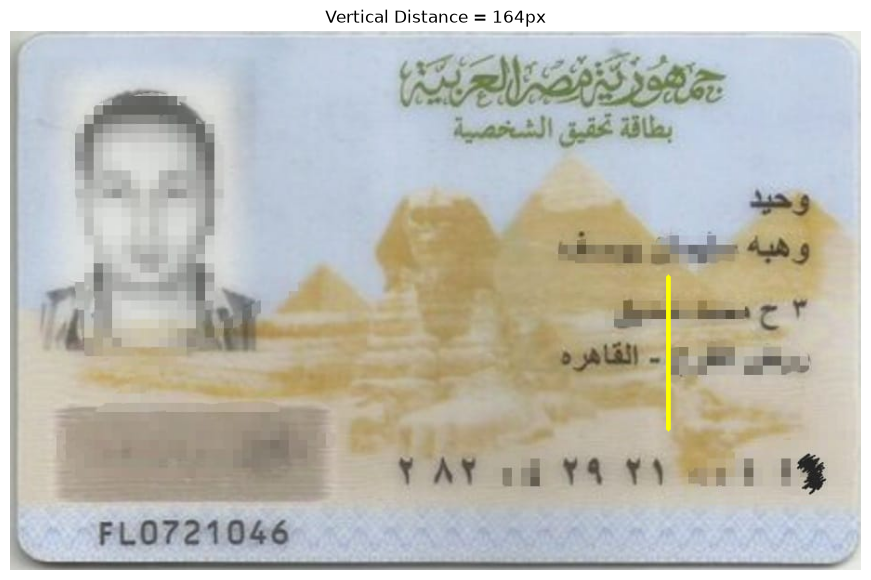

In [14]:
distance_image = card.copy()

x = int((name_x1 + name_x2) / 2)

cv2.line(
    distance_image,
    (x, name_y2),
    (x, num_y1),
    (0, 255, 255),
    3
)

plt.figure(figsize=(12, 7))

plt.imshow(
    cv2.cvtColor(
        distance_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Vertical Distance = {distance}px"
)

plt.axis("off")

plt.show()

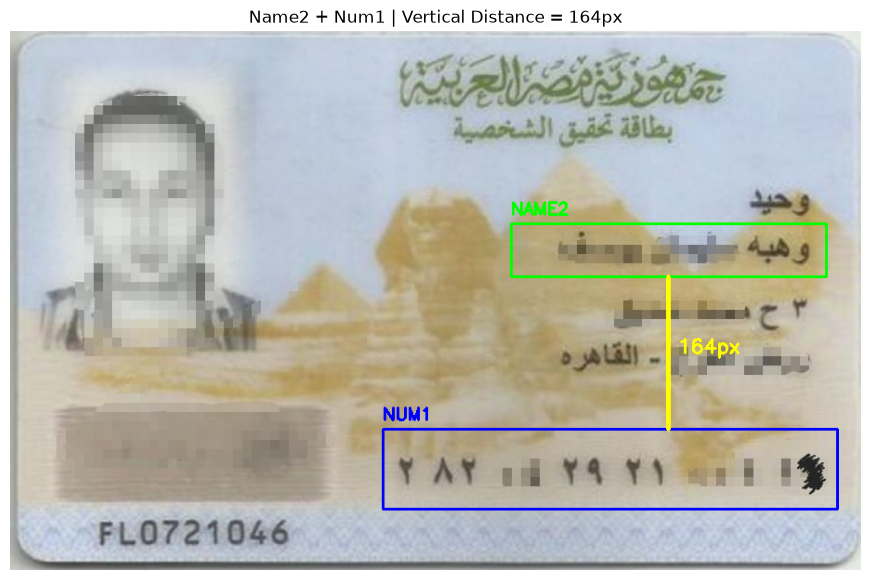

In [15]:
result_image = card.copy()

cv2.rectangle(
    result_image,
    (name_x1, name_y1),
    (name_x2, name_y2),
    (0, 255, 0),
    2
)

cv2.putText(
    result_image,
    "NAME2",
    (name_x1, name_y1 - 10),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.6,
    (0, 255, 0),
    2
)

cv2.rectangle(
    result_image,
    (num_x1, num_y1),
    (num_x2, num_y2),
    (255, 0, 0),
    2
)

cv2.putText(
    result_image,
    "NUM1",
    (num_x1, num_y1 - 10),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.6,
    (255, 0, 0),
    2
)

x = int((name_x1 + name_x2) / 2)

cv2.line(
    result_image,
    (x, name_y2),
    (x, num_y1),
    (0, 255, 255),
    3
)

cv2.putText(
    result_image,
    f"{distance}px",
    (x + 10, int((name_y2 + num_y1) / 2)),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.7,
    (0, 255, 255),
    2
)

plt.figure(figsize=(12, 7))

plt.imshow(
    cv2.cvtColor(
        result_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Name2 + Num1 | Vertical Distance = {distance}px"
)

plt.axis("off")

plt.show()